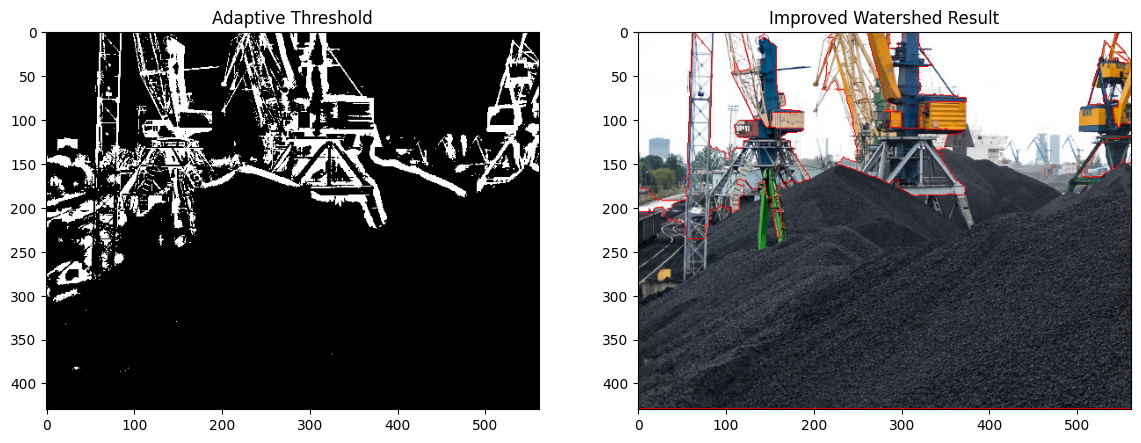

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread(r"washeries.jpg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Smooth but preserve edges
gray_blur = cv2.bilateralFilter(gray, 15, 75, 75)

# Adaptive threshold for textured background
th = cv2.adaptiveThreshold(gray_blur, 255,
                           cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                           cv2.THRESH_BINARY_INV,
                           21, 5)

# Morphological closing helps unify washer shapes
kernel = np.ones((5,5), np.uint8)
closing = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=2)

# Distance transform
dist = cv2.distanceTransform(closing, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.35 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Background
sure_bg = cv2.dilate(closing, kernel, iterations=3)
unknown = cv2.subtract(sure_bg, sure_fg)

# Markers
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# Apply watershed
markers = cv2.watershed(img, markers)

result = img.copy()
result[markers == -1] = [0,0,255]

plt.figure(figsize=(14,7))
plt.subplot(1,2,1); plt.title("Adaptive Threshold"); plt.imshow(th, cmap='gray')
plt.subplot(1,2,2); plt.title("Improved Watershed Result"); plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.show()